# Minería de Datos — Clase 6: Clustering

**Alumno:** Gallego, Ian  
**Materia:** Minería de Datos  
**Institución:** Politécnico Malvinas Argentinas  
**Fecha:** Mayo 2026

---

## Contenido

| Sección | Tema |
|---------|------|
| 1 | Introducción al Clustering |
| 2 | Algoritmo K-Means + Ejercicio (Dataset Penguins) |
| 3 | Algoritmo DBScan + Ejercicio (Dataset Iris) |
| 4 | Evaluación de la Calidad del Clustering + Ejercicio (Dataset Diamonds) |
| 5 | Ejercicio Integrador — Dataset Online Retail (UCI) |

In [1]:
# Instalar dependencias si es necesario
import subprocess, sys
pkgs = ["scikit-learn", "pandas", "numpy", "matplotlib", "seaborn", "openpyxl"]
for pkg in pkgs:
    try:
        __import__(pkg.replace("-","_").split(".")[0])
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

import sklearn
print("Librerías cargadas correctamente.")
print(f"scikit-learn {sklearn.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

Librerías cargadas correctamente.
scikit-learn 1.8.0 | pandas 3.0.2 | numpy 2.4.4


---
## Sección 1: Introducción al Clustering

### ¿Qué es el Clustering?

El **clustering** (agrupamiento) es una técnica de **aprendizaje no supervisado** que agrupa un conjunto de datos en subconjuntos llamados **clusters**, de forma que los elementos dentro de un cluster sean más similares entre sí que con los de otros clusters.

A diferencia del aprendizaje supervisado, **no se necesitan etiquetas**: el algoritmo descubre la estructura subyacente de los datos por sí mismo.

### Tipos de Clustering

| Tipo | Algoritmo típico | Cuándo usarlo |
|------|-----------------|---------------|
| **Particional** | K-Means | Cuando se conoce (o estima) el número de grupos |
| **Basado en densidad** | DBScan | Cuando hay ruido/outliers o clusters de forma irregular |
| **Jerárquico** | Ward, Agglomerative | Cuando se quiere explorar jerarquías de agrupamiento |
| **Redes neuronales** | SOM (Self-Organizing Maps) | Representaciones complejas de alta dimensión |

### Aplicaciones
- **Segmentación de clientes** (marketing)
- **Detección de anomalías** (fraude bancario)
- **Compresión de imágenes**
- **Agrupamiento de documentos** (NLP)
- **Análisis de comportamiento de usuarios**

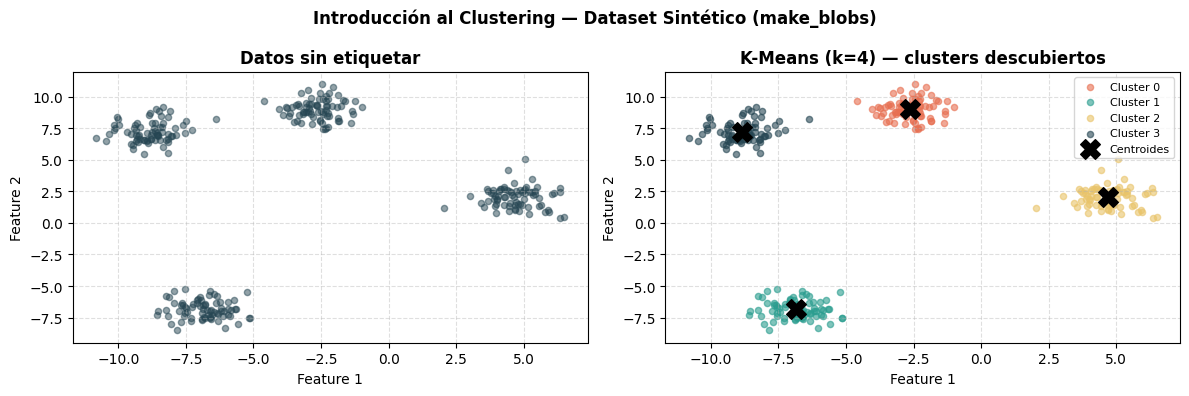

→ K-Means encontró automáticamente los 4 grupos sin conocer las etiquetas reales.


In [2]:
# Ejemplo introductorio: dataset sintético con make_blobs
X_blob, y_blob = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Introducción al Clustering — Dataset Sintético (make_blobs)",
             fontsize=12, fontweight='bold')

# Sin etiquetar
axes[0].scatter(X_blob[:, 0], X_blob[:, 1], alpha=0.5, s=20, color='#264653')
axes[0].set_title("Datos sin etiquetar", fontweight='bold')
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2")
axes[0].grid(linestyle='--', alpha=0.4)

# Con K-Means
km_intro = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_intro = km_intro.fit_predict(X_blob)
palette = ["#e76f51", "#2a9d8f", "#e9c46a", "#264653"]
for k in range(4):
    mask = labels_intro == k
    axes[1].scatter(X_blob[mask, 0], X_blob[mask, 1],
                   alpha=0.6, s=20, color=palette[k], label=f"Cluster {k}")
axes[1].scatter(km_intro.cluster_centers_[:, 0], km_intro.cluster_centers_[:, 1],
               marker='X', s=200, c='black', zorder=5, label='Centroides')
axes[1].set_title("K-Means (k=4) — clusters descubiertos", fontweight='bold')
axes[1].set_xlabel("Feature 1"); axes[1].set_ylabel("Feature 2")
axes[1].legend(fontsize=8); axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
print("→ K-Means encontró automáticamente los 4 grupos sin conocer las etiquetas reales.")

---
## Sección 2: Algoritmo K-Means

### ¿Cómo funciona K-Means?

K-Means es un algoritmo **iterativo** que divide los datos en **K clusters** minimizando la inercia (suma de distancias al cuadrado entre cada punto y su centroide):

$$\text{Inercia} = \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2$$

**Pasos:**
1. **Inicialización:** colocar K centroides aleatoriamente (o con K-Means++)
2. **Asignación:** cada punto se asigna al centroide más cercano
3. **Actualización:** recalcular cada centroide como la media de los puntos asignados
4. **Repetir** pasos 2–3 hasta convergencia

### Método del Codo (Elbow Method)
Para elegir K óptimo: graficar la inercia vs. K y buscar el "codo" donde la reducción de inercia se estabiliza.

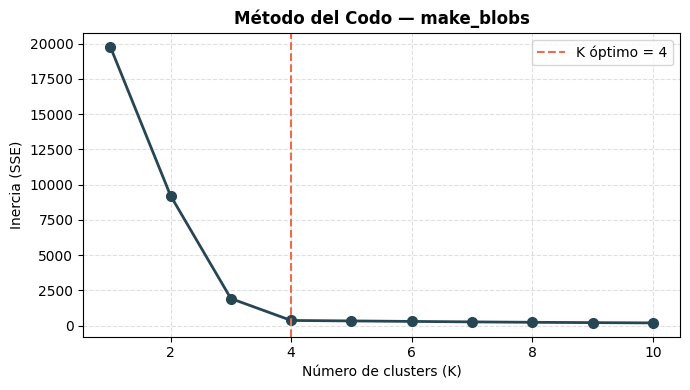

→ El 'codo' se observa en K=4, confirmando el número real de grupos en el dataset.


In [3]:
# Demostración del Método del Codo
inercias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blob)
    inercias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inercias, 'o-', color='#264653', linewidth=2, markersize=7)
plt.axvline(x=4, color='#e76f51', linestyle='--', linewidth=1.5, label='K óptimo = 4')
plt.title("Método del Codo — make_blobs", fontweight='bold')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia (SSE)")
plt.legend()
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print("→ El 'codo' se observa en K=4, confirmando el número real de grupos en el dataset.")

### Ejercicio — Sección 2: Dataset Penguins

**Objetivo:** Aplicar K-Means al dataset de pingüinos usando las features `bill_length_mm` y `bill_depth_mm`, y determinar el número óptimo de clusters con el método del codo.

Dataset Penguins: 342 muestras
Especies reales: ['Adelie', 'Chinstrap', 'Gentoo']


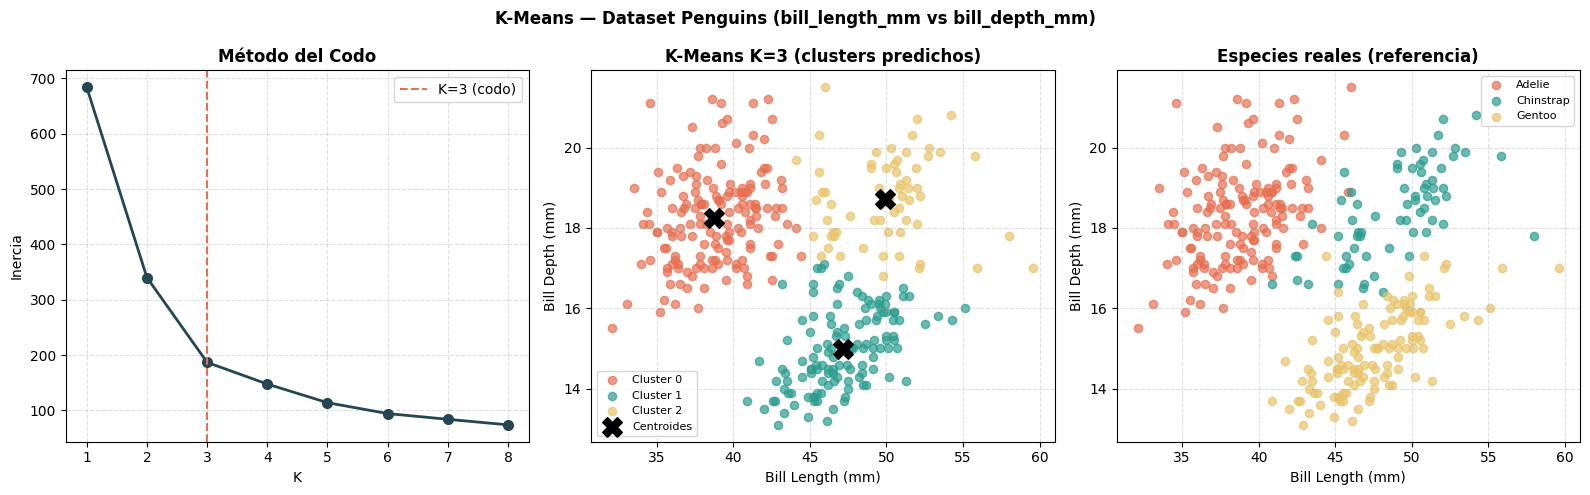

Silhouette Score (K=3): 0.5245
→ K=3 coincide con las 3 especies reales: Adelie, Chinstrap y Gentoo.
→ K-Means logra separar bien los grupos usando solo las dimensiones del pico.


In [4]:
# Cargar dataset Penguins
penguins = sns.load_dataset("penguins").dropna(subset=["bill_length_mm", "bill_depth_mm"])
X_peng = penguins[["bill_length_mm", "bill_depth_mm"]].values

print(f"Dataset Penguins: {penguins.shape[0]} muestras")
print(f"Especies reales: {penguins['species'].unique().tolist()}")

# Escalar (buena práctica antes de K-Means)
scaler_peng = StandardScaler()
X_peng_sc = scaler_peng.fit_transform(X_peng)

# Método del codo
inercias_peng = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_peng_sc).inertia_
                 for k in range(1, 9)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("K-Means — Dataset Penguins (bill_length_mm vs bill_depth_mm)",
             fontsize=12, fontweight='bold')

# Codo
axes[0].plot(range(1, 9), inercias_peng, 'o-', color='#264653', linewidth=2, markersize=7)
axes[0].axvline(x=3, color='#e76f51', linestyle='--', label='K=3 (codo)')
axes[0].set_title("Método del Codo", fontweight='bold')
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inercia")
axes[0].legend(); axes[0].grid(linestyle='--', alpha=0.4)

# K-Means con K=3
km_peng = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_peng = km_peng.fit_predict(X_peng_sc)
colores_peng = ["#e76f51", "#2a9d8f", "#e9c46a"]
for k in range(3):
    mask = labels_peng == k
    axes[1].scatter(X_peng[mask, 0], X_peng[mask, 1],
                   alpha=0.7, s=35, color=colores_peng[k], label=f"Cluster {k}")
# Centroides en escala original
centroides_orig = scaler_peng.inverse_transform(km_peng.cluster_centers_)
axes[1].scatter(centroides_orig[:, 0], centroides_orig[:, 1],
               marker='X', s=200, c='black', zorder=5, label='Centroides')
axes[1].set_title("K-Means K=3 (clusters predichos)", fontweight='bold')
axes[1].set_xlabel("Bill Length (mm)"); axes[1].set_ylabel("Bill Depth (mm)")
axes[1].legend(fontsize=8); axes[1].grid(linestyle='--', alpha=0.4)

# Especies reales para comparar
species_palette = {"Adelie": "#e76f51", "Chinstrap": "#2a9d8f", "Gentoo": "#e9c46a"}
for sp, color in species_palette.items():
    mask = penguins["species"] == sp
    axes[2].scatter(penguins.loc[mask, "bill_length_mm"],
                   penguins.loc[mask, "bill_depth_mm"],
                   alpha=0.7, s=35, color=color, label=sp)
axes[2].set_title("Especies reales (referencia)", fontweight='bold')
axes[2].set_xlabel("Bill Length (mm)"); axes[2].set_ylabel("Bill Depth (mm)")
axes[2].legend(fontsize=8); axes[2].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

sil_peng = silhouette_score(X_peng_sc, labels_peng)
print(f"Silhouette Score (K=3): {sil_peng:.4f}")
print("→ K=3 coincide con las 3 especies reales: Adelie, Chinstrap y Gentoo.")
print("→ K-Means logra separar bien los grupos usando solo las dimensiones del pico.")

---
## Sección 3: Algoritmo DBScan

### ¿Cómo funciona DBScan?

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** agrupa puntos según su **densidad local**. No requiere especificar K de antemano.

**Parámetros clave:**
- **ε (epsilon):** radio de vecindad alrededor de un punto
- **minPts:** mínimo de puntos dentro del radio ε para considerar un punto como *núcleo*

**Tipos de puntos:**
- **Punto núcleo:** tiene al menos `minPts` vecinos en radio ε
- **Punto borde:** vecino de un núcleo pero sin suficientes vecinos propios
- **Ruido (outlier):** no es núcleo ni borde — etiquetado como **-1**

**Ventajas vs K-Means:**
- Detecta clusters de forma arbitraria (no solo esférica)
- Identifica outliers automáticamente
- No requiere especificar K

**Desventajas:**
- Sensible a la elección de ε y minPts
- Dificultades con densidades variables entre clusters
- Más lento en datasets muy grandes

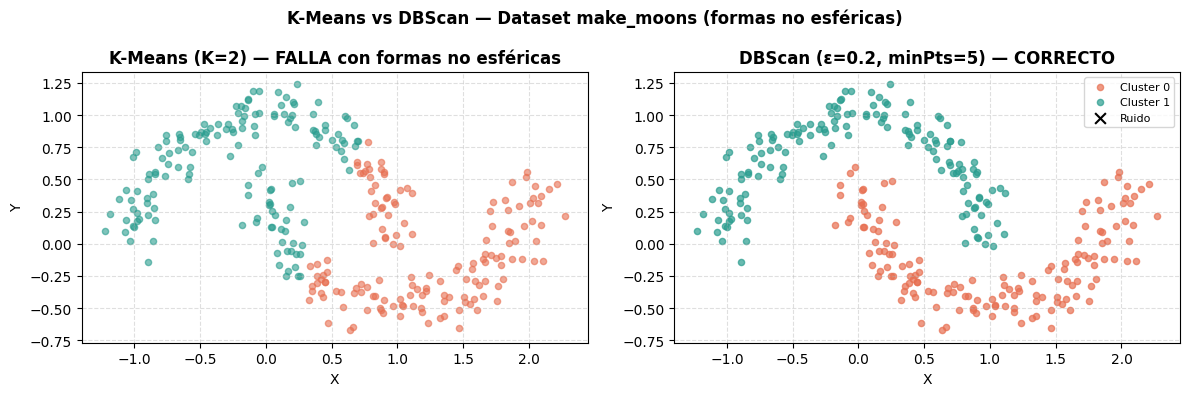

DBScan detectó: 2 clusters | 0 puntos de ruido


In [5]:
# Demostración: DBScan en make_moons (formas no esféricas)
X_moons, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("K-Means vs DBScan — Dataset make_moons (formas no esféricas)",
             fontsize=12, fontweight='bold')

# K-Means falla con formas no esféricas
labels_km_moons = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_moons)
for k, col in enumerate(["#e76f51", "#2a9d8f"]):
    mask = labels_km_moons == k
    axes[0].scatter(X_moons[mask, 0], X_moons[mask, 1], color=col, alpha=0.6, s=20)
axes[0].set_title("K-Means (K=2) — FALLA con formas no esféricas", fontweight='bold')
axes[0].set_xlabel("X"); axes[0].set_ylabel("Y")
axes[0].grid(linestyle='--', alpha=0.4)

# DBScan maneja bien las lunas
db_moons = DBSCAN(eps=0.2, min_samples=5)
labels_db_moons = db_moons.fit_predict(X_moons)
colores_db = {0: "#e76f51", 1: "#2a9d8f", -1: "black"}
for lbl, col in colores_db.items():
    mask = labels_db_moons == lbl
    nombre = f"Cluster {lbl}" if lbl >= 0 else "Ruido"
    axes[1].scatter(X_moons[mask, 0], X_moons[mask, 1],
                   color=col, alpha=0.7 if lbl >= 0 else 1.0,
                   s=20 if lbl >= 0 else 60,
                   marker='o' if lbl >= 0 else 'x', label=nombre)
axes[1].set_title("DBScan (ε=0.2, minPts=5) — CORRECTO", fontweight='bold')
axes[1].set_xlabel("X"); axes[1].set_ylabel("Y")
axes[1].legend(fontsize=8); axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

n_clusters_db = len(set(labels_db_moons)) - (1 if -1 in labels_db_moons else 0)
n_ruido = (labels_db_moons == -1).sum()
print(f"DBScan detectó: {n_clusters_db} clusters | {n_ruido} puntos de ruido")

### Ejercicio — Sección 3: Dataset Iris — K-Means vs DBScan

**Objetivo:** Comparar K-Means y DBScan usando `sepal_length` y `sepal_width` del dataset Iris.

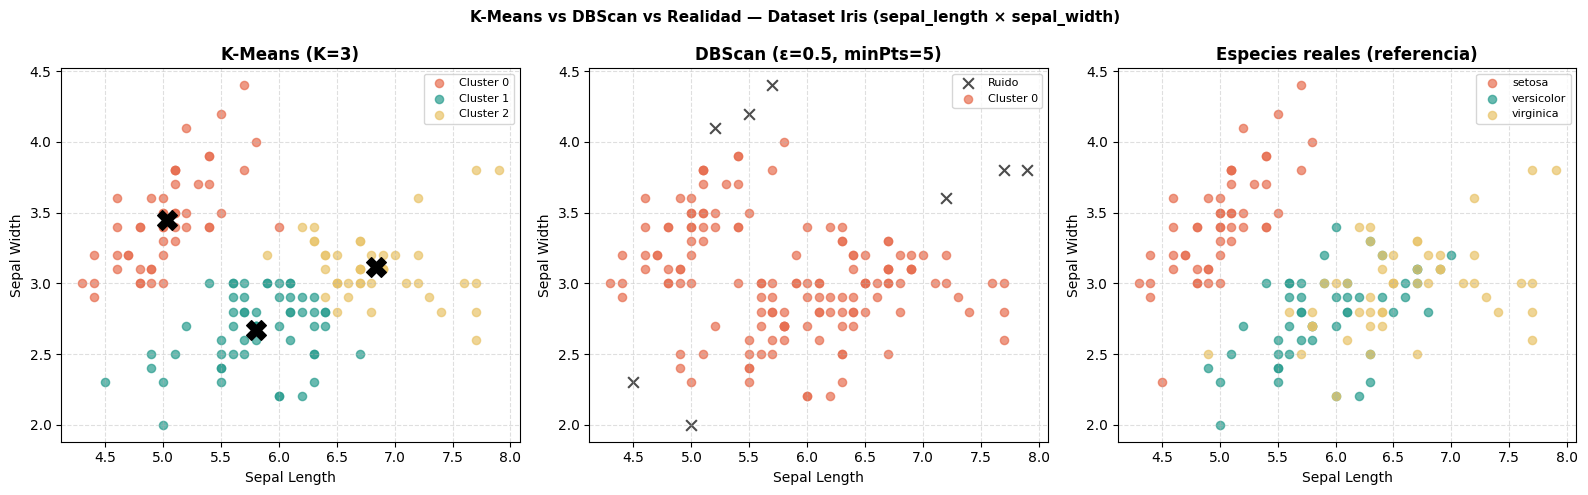

K-Means  — Silhouette: 0.4389 | Clusters: 3
DBScan   — Silhouette: nan | Clusters: 1 | Ruido: 8 puntos

→ En este espacio 2D, K-Means y DBScan tienen dificultades separando
  Versicolor y Virginica (se solapan en sepal_length/sepal_width).
→ Con las 4 features completas, la separación mejoraría significativamente.


In [6]:
# Cargar Iris
iris = sns.load_dataset("iris")
X_iris = iris[["sepal_length", "sepal_width"]].values

scaler_iris = StandardScaler()
X_iris_sc = scaler_iris.fit_transform(X_iris)

# K-Means K=3
km_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km_iris = km_iris.fit_predict(X_iris_sc)

# DBScan — ajustamos eps para obtener 3 clusters
db_iris = DBSCAN(eps=0.5, min_samples=5)
labels_db_iris = db_iris.fit_predict(X_iris_sc)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("K-Means vs DBScan vs Realidad — Dataset Iris (sepal_length × sepal_width)",
             fontsize=11, fontweight='bold')

paleta3 = ["#e76f51", "#2a9d8f", "#e9c46a"]

# K-Means
for k in range(3):
    mask = labels_km_iris == k
    axes[0].scatter(X_iris[mask, 0], X_iris[mask, 1],
                   color=paleta3[k], alpha=0.7, s=35, label=f"Cluster {k}")
centroides_iris = scaler_iris.inverse_transform(km_iris.cluster_centers_)
axes[0].scatter(centroides_iris[:, 0], centroides_iris[:, 1],
               marker='X', s=200, c='black', zorder=5)
axes[0].set_title("K-Means (K=3)", fontweight='bold')
axes[0].set_xlabel("Sepal Length"); axes[0].set_ylabel("Sepal Width")
axes[0].legend(fontsize=8); axes[0].grid(linestyle='--', alpha=0.4)

# DBScan
colores_map = {-1: 'black', 0: paleta3[0], 1: paleta3[1], 2: paleta3[2]}
unique_labels = sorted(set(labels_db_iris))
for lbl in unique_labels:
    mask = labels_db_iris == lbl
    nombre = f"Cluster {lbl}" if lbl >= 0 else "Ruido"
    color = colores_map.get(lbl, "purple")
    axes[1].scatter(X_iris[mask, 0], X_iris[mask, 1],
                   color=color, alpha=0.7, s=35 if lbl >= 0 else 60,
                   marker='o' if lbl >= 0 else 'x', label=nombre)
axes[1].set_title(f"DBScan (ε=0.5, minPts=5)", fontweight='bold')
axes[1].set_xlabel("Sepal Length"); axes[1].set_ylabel("Sepal Width")
axes[1].legend(fontsize=8); axes[1].grid(linestyle='--', alpha=0.4)

# Realidad
species_col = {"setosa": paleta3[0], "versicolor": paleta3[1], "virginica": paleta3[2]}
for sp, col in species_col.items():
    mask = iris["species"] == sp
    axes[2].scatter(iris.loc[mask, "sepal_length"], iris.loc[mask, "sepal_width"],
                   color=col, alpha=0.7, s=35, label=sp)
axes[2].set_title("Especies reales (referencia)", fontweight='bold')
axes[2].set_xlabel("Sepal Length"); axes[2].set_ylabel("Sepal Width")
axes[2].legend(fontsize=8); axes[2].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

n_clusters_iris_db = len(set(labels_db_iris)) - (1 if -1 in labels_db_iris else 0)
n_ruido_iris = (labels_db_iris == -1).sum()

sil_km_iris = silhouette_score(X_iris_sc, labels_km_iris)
if len(set(labels_db_iris)) > 1 and n_clusters_iris_db > 1:
    mask_no_noise = labels_db_iris != -1
    sil_db_iris = silhouette_score(X_iris_sc[mask_no_noise], labels_db_iris[mask_no_noise])
else:
    sil_db_iris = float('nan')

print(f"K-Means  — Silhouette: {sil_km_iris:.4f} | Clusters: 3")
print(f"DBScan   — Silhouette: {sil_db_iris:.4f} | Clusters: {n_clusters_iris_db} | Ruido: {n_ruido_iris} puntos")
print()
print("→ En este espacio 2D, K-Means y DBScan tienen dificultades separando")
print("  Versicolor y Virginica (se solapan en sepal_length/sepal_width).")
print("→ Con las 4 features completas, la separación mejoraría significativamente.")

---
## Sección 4: Evaluación de la Calidad del Clustering

### Métricas de evaluación (sin etiquetas reales)

Como el clustering es no supervisado, necesitamos métricas internas:

| Métrica | Fórmula / Idea | Interpretación |
|---------|---------------|----------------|
| **Inercia (SSE)** | Suma de dist² punto–centroide | Menor = mejor (solo K-Means) |
| **Silhouette Score** | $(b - a) / \max(a, b)$ donde $a$=cohesión, $b$=separación | Rango [-1, 1]. Más cercano a 1 = mejor |
| **Davies-Bouldin Index** | Ratio dispersión/separación entre pares | Menor = mejor (0 = perfecto) |

**Silhouette Score:** mide qué tan bien cada punto está asignado a su cluster vs. el cluster más cercano. Un valor de 1 indica perfecta separación; 0 indica puntos en la frontera; -1 indica mala asignación.

**Davies-Bouldin Index:** compara la dispersión intra-cluster con la separación inter-cluster. Un valor bajo indica clusters compactos y bien separados.

Métricas para distintos valores de K (make_blobs con 4 centros reales):


,K,Silhouette,Davies-Bouldin,Inercia
0,2,0.6030,0.5039,9211.2106
1,3,0.7783,0.3336,1919.3648
2,4,0.8335,0.2322,362.4724
3,5,0.6976,0.6251,329.2684
4,6,0.5882,0.8400,294.6057
5,7,0.4487,0.9949,261.5639
6,8,0.3322,1.1533,232.0116


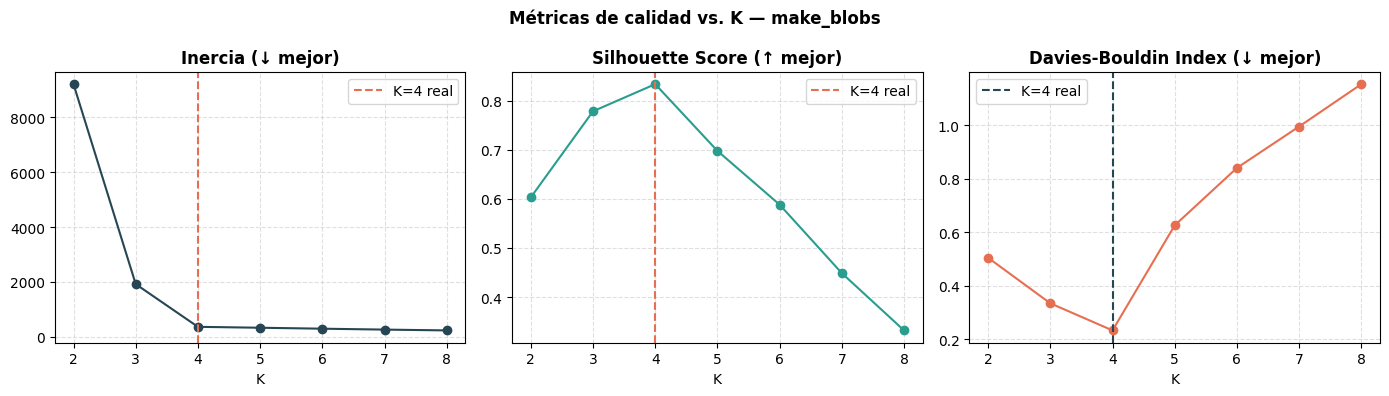

→ Las tres métricas coinciden: K=4 es el valor óptimo.


In [7]:
# Demostración de métricas con make_blobs
resultados_metrics = []
for k in range(2, 9):
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = km_temp.fit_predict(X_blob)
    sil = silhouette_score(X_blob, labels_temp)
    db  = davies_bouldin_score(X_blob, labels_temp)
    resultados_metrics.append({"K": k, "Silhouette": sil, "Davies-Bouldin": db,
                                "Inercia": km_temp.inertia_})

df_metrics = pd.DataFrame(resultados_metrics)
print("Métricas para distintos valores de K (make_blobs con 4 centros reales):")
display(df_metrics.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Métricas de calidad vs. K — make_blobs", fontweight='bold')

axes[0].plot(df_metrics["K"], df_metrics["Inercia"], 'o-', color='#264653')
axes[0].axvline(x=4, color='#e76f51', linestyle='--', label='K=4 real')
axes[0].set_title("Inercia (↓ mejor)", fontweight='bold')
axes[0].set_xlabel("K"); axes[0].legend(); axes[0].grid(linestyle='--', alpha=0.4)

axes[1].plot(df_metrics["K"], df_metrics["Silhouette"], 'o-', color='#2a9d8f')
axes[1].axvline(x=4, color='#e76f51', linestyle='--', label='K=4 real')
axes[1].set_title("Silhouette Score (↑ mejor)", fontweight='bold')
axes[1].set_xlabel("K"); axes[1].legend(); axes[1].grid(linestyle='--', alpha=0.4)

axes[2].plot(df_metrics["K"], df_metrics["Davies-Bouldin"], 'o-', color='#e76f51')
axes[2].axvline(x=4, color='#264653', linestyle='--', label='K=4 real')
axes[2].set_title("Davies-Bouldin Index (↓ mejor)", fontweight='bold')
axes[2].set_xlabel("K"); axes[2].legend(); axes[2].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
print("→ Las tres métricas coinciden: K=4 es el valor óptimo.")

### Ejercicio — Sección 4: Dataset Diamonds — carat vs price

K óptimo por Silhouette: 2


,K,Silhouette,Davies-Bouldin,Inercia
0,2,0.6330,0.5950,1332.6178
1,3,0.6252,0.5502,570.9641
2,4,0.5743,0.6563,390.9232
3,5,0.5593,0.6273,276.3838
4,6,0.5423,0.6960,222.5953
5,7,0.5423,0.7280,192.2590
6,8,0.5372,0.7087,164.3568


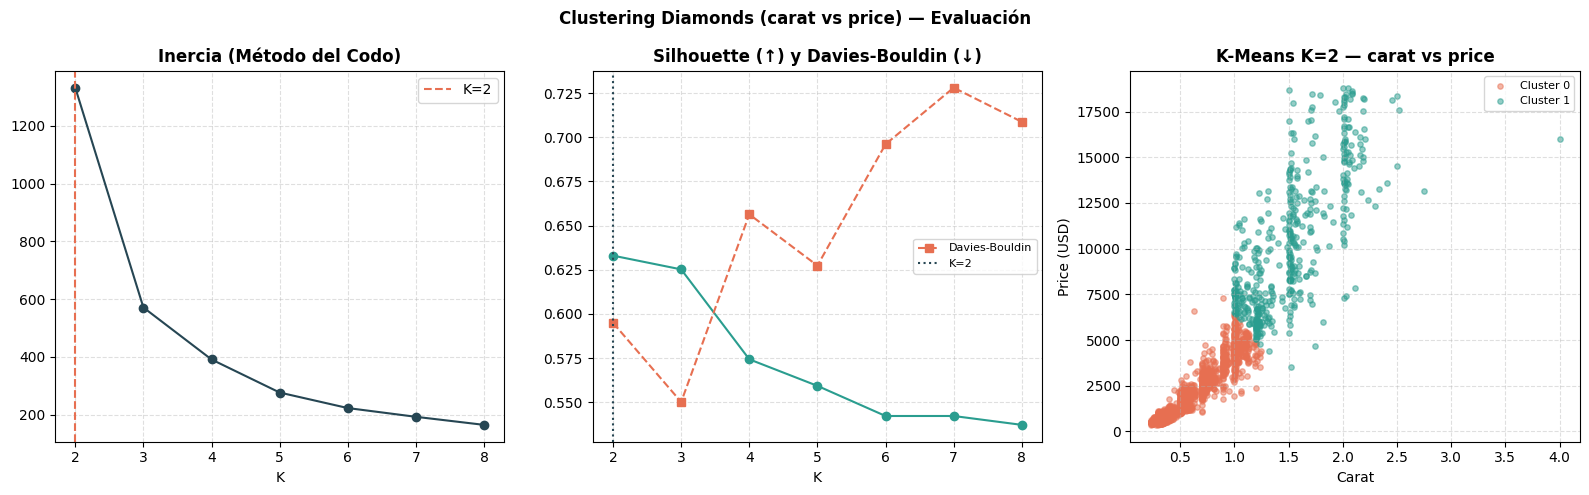

→ Los clusters identifican segmentos de diamantes por rango de quilates y precio.


In [8]:
# Dataset Diamonds — carat vs price
diamonds = sns.load_dataset("diamonds")[["carat", "price"]].sample(2000, random_state=42)
X_diam = diamonds.values

scaler_diam = StandardScaler()
X_diam_sc = scaler_diam.fit_transform(X_diam)

# Evaluar K de 2 a 8
res_diam = []
for k in range(2, 9):
    km_d = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl_d = km_d.fit_predict(X_diam_sc)
    res_diam.append({
        "K": k,
        "Silhouette":     silhouette_score(X_diam_sc, lbl_d),
        "Davies-Bouldin": davies_bouldin_score(X_diam_sc, lbl_d),
        "Inercia":        km_d.inertia_
    })

df_diam = pd.DataFrame(res_diam)
k_opt = df_diam.loc[df_diam["Silhouette"].idxmax(), "K"]
print(f"K óptimo por Silhouette: {int(k_opt)}")
display(df_diam.round(4))

# Ajustar con K óptimo y visualizar
km_diam_final = KMeans(n_clusters=int(k_opt), random_state=42, n_init=10)
labels_diam = km_diam_final.fit_predict(X_diam_sc)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Clustering Diamonds (carat vs price) — Evaluación",
             fontsize=12, fontweight='bold')

# Codo
axes[0].plot(df_diam["K"], df_diam["Inercia"], 'o-', color='#264653')
axes[0].axvline(x=k_opt, color='#e76f51', linestyle='--', label=f'K={int(k_opt)}')
axes[0].set_title("Inercia (Método del Codo)", fontweight='bold')
axes[0].set_xlabel("K"); axes[0].legend(); axes[0].grid(linestyle='--', alpha=0.4)

# Silhouette
axes[1].plot(df_diam["K"], df_diam["Silhouette"], 'o-', color='#2a9d8f')
axes[1].plot(df_diam["K"], df_diam["Davies-Bouldin"], 's--', color='#e76f51', label='Davies-Bouldin')
axes[1].axvline(x=k_opt, color='#264653', linestyle=':', label=f'K={int(k_opt)}')
axes[1].set_title("Silhouette (↑) y Davies-Bouldin (↓)", fontweight='bold')
axes[1].set_xlabel("K"); axes[1].legend(fontsize=8); axes[1].grid(linestyle='--', alpha=0.4)

# Scatter con clusters
colores_diam = ["#e76f51", "#2a9d8f", "#e9c46a", "#264653", "#a8dadc"]
for k in range(int(k_opt)):
    mask = labels_diam == k
    axes[2].scatter(X_diam[mask, 0], X_diam[mask, 1],
                   color=colores_diam[k], alpha=0.5, s=15, label=f"Cluster {k}")
axes[2].set_title(f"K-Means K={int(k_opt)} — carat vs price", fontweight='bold')
axes[2].set_xlabel("Carat"); axes[2].set_ylabel("Price (USD)")
axes[2].legend(fontsize=8); axes[2].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
print(f"→ Los clusters identifican segmentos de diamantes por rango de quilates y precio.")

---
## Sección 5: Ejercicio Integrador — Dataset Online Retail (UCI)

### Contexto del problema

Somos analistas de una empresa de comercio electrónico. Disponemos de un dataset con todas las transacciones entre diciembre de 2010 y diciembre de 2011. El objetivo es **segmentar clientes** para diseñar estrategias de marketing diferenciadas.

### Pipeline a aplicar
1. **Preprocesamiento:** eliminar nulos, transacciones canceladas y precios inválidos
2. **Feature Engineering:** agregar por cliente → TotalCompras, CantidadTotal, GastoTotal, Frecuencia
3. **Normalización:** StandardScaler
4. **Clustering:** K-Means (con codo) y DBScan
5. **Evaluación:** Silhouette Score y Davies-Bouldin Index
6. **Visualización y reflexión**

In [9]:
# ── PASO 1: Cargar y explorar el dataset ──────────────────────────────────
print("Cargando Online Retail.xlsx ... (puede tomar unos segundos)")
df_retail = pd.read_excel("Online Retail.xlsx", engine="openpyxl")

print(f"\nShape original: {df_retail.shape}")
print(f"Columnas: {df_retail.columns.tolist()}")
print(f"\nValores nulos por columna:")
print(df_retail.isnull().sum())
print(f"\nEjemplos:")
display(df_retail.head(3))
print(f"\nRango de fechas: {df_retail['InvoiceDate'].min()} → {df_retail['InvoiceDate'].max()}")
print(f"Países únicos:   {df_retail['Country'].nunique()}")
print(f"Clientes únicos: {df_retail['CustomerID'].nunique()}")

Cargando Online Retail.xlsx ... (puede tomar unos segundos)

Shape original: (541909, 8)
Columnas: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Valores nulos por columna:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Ejemplos:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom



Rango de fechas: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Países únicos:   38
Clientes únicos: 4372


In [10]:
# ── PASO 2: Limpieza de datos ─────────────────────────────────────────────
n_orig = len(df_retail)

# a) Eliminar filas sin CustomerID (no podemos asignar transacción a un cliente)
df_clean = df_retail.dropna(subset=["CustomerID"]).copy()
print(f"Tras eliminar nulos en CustomerID: {len(df_clean):,} filas "
      f"(eliminadas: {n_orig - len(df_clean):,})")

# b) Eliminar transacciones canceladas (InvoiceNo que comienzan con 'C')
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith('C')]
print(f"Tras eliminar cancelaciones:       {len(df_clean):,} filas")

# c) Eliminar cantidades y precios negativos o cero
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]
print(f"Tras filtrar Quantity/Price > 0:   {len(df_clean):,} filas")

# d) Convertir CustomerID a entero
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

# e) Calcular TotalPrecio por línea
df_clean["TotalLinea"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print(f"\nDataset limpio: {len(df_clean):,} filas ({len(df_clean)/n_orig*100:.1f}% del original)")
print(f"Clientes únicos tras limpieza: {df_clean['CustomerID'].nunique():,}")
display(df_clean.head(3))

Tras eliminar nulos en CustomerID: 406,829 filas (eliminadas: 135,080)
Tras eliminar cancelaciones:       397,924 filas
Tras filtrar Quantity/Price > 0:   397,884 filas

Dataset limpio: 397,884 filas (73.4% del original)
Clientes únicos tras limpieza: 4,338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalLinea
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00


Dataset de clientes: (4338, 5)

Estadísticas descriptivas:


,CustomerID,TotalCompras,CantidadTotal,GastoTotal,Frecuencia
count,4338.00,4338.00,4338.00,4338.00,4338.00
mean,15300.41,4.27,1191.29,2054.27,91.72
std,1721.81,7.70,5046.08,8989.23,228.79
min,12346.00,1.00,1.00,3.75,1.00
25%,13813.25,1.00,160.00,307.41,17.00
50%,15299.50,2.00,379.00,674.48,41.00
75%,16778.75,5.00,992.75,1661.74,100.00
max,18287.00,209.00,196915.00,280206.02,7847.00



Ejemplos:


,CustomerID,TotalCompras,CantidadTotal,GastoTotal,Frecuencia
0,12346,1,74215,77183.60,1
1,12347,7,2458,4310.00,182
2,12348,4,2341,1797.24,31
3,12349,1,631,1757.55,73
4,12350,1,197,334.40,17


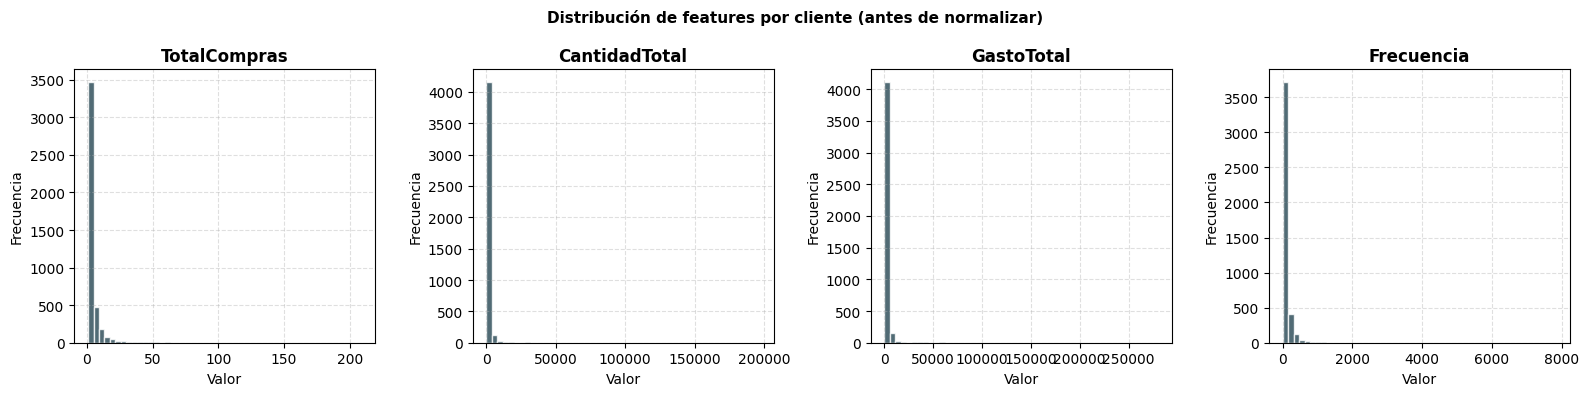

→ Las distribuciones tienen cola larga (outliers). Esto es típico en datos de compras.


In [11]:
# ── PASO 3: Feature Engineering — agregar por CustomerID ─────────────────
clientes = df_clean.groupby("CustomerID").agg(
    TotalCompras  = ("InvoiceNo",  "nunique"),   # facturas únicas
    CantidadTotal = ("Quantity",   "sum"),        # unidades totales compradas
    GastoTotal    = ("TotalLinea", "sum"),        # gasto total en £
    Frecuencia    = ("InvoiceNo",  "count")       # líneas de pedido totales
).reset_index()

print(f"Dataset de clientes: {clientes.shape}")
print(f"\nEstadísticas descriptivas:")
display(clientes.describe().round(2))
print(f"\nEjemplos:")
display(clientes.head(5))

# Visualizar distribuciones antes de normalizar
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Distribución de features por cliente (antes de normalizar)",
             fontsize=11, fontweight='bold')
features_plot = ["TotalCompras", "CantidadTotal", "GastoTotal", "Frecuencia"]
for ax, col in zip(axes, features_plot):
    ax.hist(clientes[col], bins=50, color='#264653', alpha=0.8, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel("Valor"); ax.set_ylabel("Frecuencia")
    ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print("→ Las distribuciones tienen cola larga (outliers). Esto es típico en datos de compras.")

In [12]:
# ── PASO 4: Normalización ─────────────────────────────────────────────────
# Usamos log1p para comprimir la cola larga ANTES de escalar
features_modelo = ["TotalCompras", "CantidadTotal", "GastoTotal", "Frecuencia"]
clientes_log = clientes.copy()
for col in features_modelo:
    clientes_log[col] = np.log1p(clientes[col])

scaler_retail = StandardScaler()
X_retail = scaler_retail.fit_transform(clientes_log[features_modelo])

print(f"Matriz para clustering: {X_retail.shape}")
print(f"Media por feature tras escalar: {X_retail.mean(axis=0).round(6)}")
print(f"Std  por feature tras escalar:  {X_retail.std(axis=0).round(6)}")
print("\n→ Log1p + StandardScaler: se reduce el impacto de outliers extremos y")
print("  se normalizan las escalas para que todas las features pesen igual.")

Matriz para clustering: (4338, 4)
Media por feature tras escalar: [-0.  0.  0. -0.]
Std  por feature tras escalar:  [1. 1. 1. 1.]

→ Log1p + StandardScaler: se reduce el impacto de outliers extremos y
  se normalizan las escalas para que todas las features pesen igual.


K óptimo por Silhouette: 2


,K,Inercia,Silhouette,Davies-Bouldin
0,2,7812.7640,0.4648,0.7759
1,3,5378.3044,0.3707,0.8798
2,4,4316.4193,0.3261,0.9425
3,5,3665.1346,0.2997,1.0163
4,6,3343.8049,0.2667,1.0994
5,7,3100.0628,0.2724,1.1089
6,8,2881.1757,0.2412,1.1663
7,9,2696.9799,0.2327,1.1793
8,10,2547.7697,0.2382,1.1801


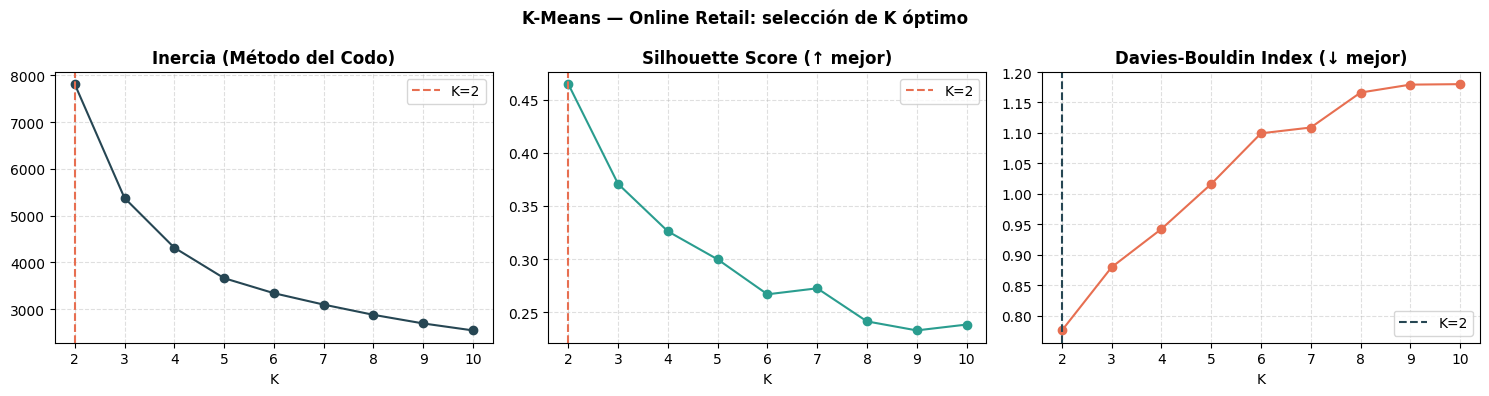


Distribución de clientes por cluster (K-Means K=2):
Cluster_KMeans
0    2613
1    1725


In [13]:
# ── PASO 5a: K-Means con Método del Codo ─────────────────────────────────
resultados_km = []
K_vals = range(2, 11)
for k in K_vals:
    km_r = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl_r = km_r.fit_predict(X_retail)
    resultados_km.append({
        "K":              k,
        "Inercia":        km_r.inertia_,
        "Silhouette":     silhouette_score(X_retail, lbl_r),
        "Davies-Bouldin": davies_bouldin_score(X_retail, lbl_r)
    })

df_km_res = pd.DataFrame(resultados_km)
k_opt_retail = int(df_km_res.loc[df_km_res["Silhouette"].idxmax(), "K"])
print(f"K óptimo por Silhouette: {k_opt_retail}")
display(df_km_res.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("K-Means — Online Retail: selección de K óptimo", fontweight='bold')

axes[0].plot(df_km_res["K"], df_km_res["Inercia"], 'o-', color='#264653')
axes[0].axvline(x=k_opt_retail, color='#e76f51', linestyle='--', label=f'K={k_opt_retail}')
axes[0].set_title("Inercia (Método del Codo)", fontweight='bold')
axes[0].set_xlabel("K"); axes[0].legend(); axes[0].grid(linestyle='--', alpha=0.4)

axes[1].plot(df_km_res["K"], df_km_res["Silhouette"], 'o-', color='#2a9d8f')
axes[1].axvline(x=k_opt_retail, color='#e76f51', linestyle='--', label=f'K={k_opt_retail}')
axes[1].set_title("Silhouette Score (↑ mejor)", fontweight='bold')
axes[1].set_xlabel("K"); axes[1].legend(); axes[1].grid(linestyle='--', alpha=0.4)

axes[2].plot(df_km_res["K"], df_km_res["Davies-Bouldin"], 'o-', color='#e76f51')
axes[2].axvline(x=k_opt_retail, color='#264653', linestyle='--', label=f'K={k_opt_retail}')
axes[2].set_title("Davies-Bouldin Index (↓ mejor)", fontweight='bold')
axes[2].set_xlabel("K"); axes[2].legend(); axes[2].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Entrenar K-Means final
km_retail_final = KMeans(n_clusters=k_opt_retail, random_state=42, n_init=10)
labels_km_retail = km_retail_final.fit_predict(X_retail)
clientes["Cluster_KMeans"] = labels_km_retail

print(f"\nDistribución de clientes por cluster (K-Means K={k_opt_retail}):")
print(clientes["Cluster_KMeans"].value_counts().sort_index().to_string())

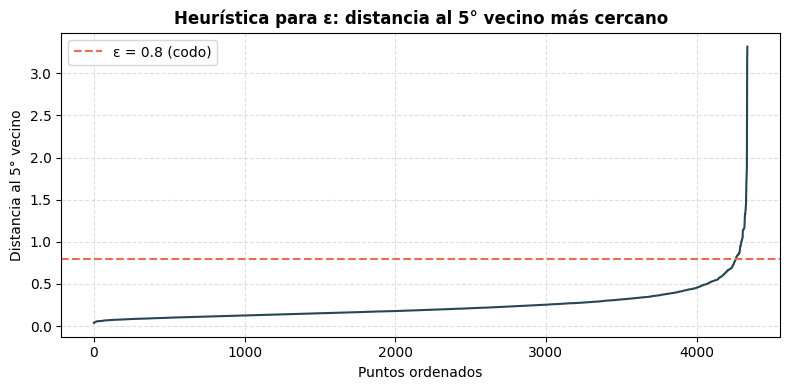

DBScan (ε=0.8, minPts=5):
  Clusters encontrados: 2
  Clientes ruido (outliers): 40 (0.9%)

Distribución (incluye -1 = ruido):
Cluster_DBScan
-1      40
 0    4292
 1       6


In [14]:
# ── PASO 5b: DBScan ───────────────────────────────────────────────────────
# Ajustar eps usando la distancia al k-ésimo vecino más cercano (heurística)
from sklearn.neighbors import NearestNeighbors

k_nn = 5
nn = NearestNeighbors(n_neighbors=k_nn)
nn.fit(X_retail)
distancias, _ = nn.kneighbors(X_retail)
distancias_k = np.sort(distancias[:, k_nn - 1])

plt.figure(figsize=(8, 4))
plt.plot(distancias_k, color='#264653', linewidth=1.5)
plt.axhline(y=0.8, color='#e76f51', linestyle='--', label='ε = 0.8 (codo)')
plt.title("Heurística para ε: distancia al 5° vecino más cercano", fontweight='bold')
plt.xlabel("Puntos ordenados"); plt.ylabel("Distancia al 5° vecino")
plt.legend(); plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

# Aplicar DBScan
eps_val = 0.8
db_retail = DBSCAN(eps=eps_val, min_samples=5, n_jobs=-1)
labels_db_retail = db_retail.fit_predict(X_retail)
clientes["Cluster_DBScan"] = labels_db_retail

n_clusters_db_r = len(set(labels_db_retail)) - (1 if -1 in labels_db_retail else 0)
n_ruido_r = (labels_db_retail == -1).sum()
n_ruido_pct = n_ruido_r / len(labels_db_retail) * 100

print(f"DBScan (ε={eps_val}, minPts=5):")
print(f"  Clusters encontrados: {n_clusters_db_r}")
print(f"  Clientes ruido (outliers): {n_ruido_r} ({n_ruido_pct:.1f}%)")
print(f"\nDistribución (incluye -1 = ruido):")
print(clientes["Cluster_DBScan"].value_counts().sort_index().to_string())

In [15]:
# ── PASO 6: Evaluación comparativa ───────────────────────────────────────
sil_km_r = silhouette_score(X_retail, labels_km_retail)
db_km_r  = davies_bouldin_score(X_retail, labels_km_retail)

# DBScan: calcular solo sobre puntos no-ruido
mask_no_ruido = labels_db_retail != -1
if mask_no_ruido.sum() > 1 and len(set(labels_db_retail[mask_no_ruido])) > 1:
    sil_db_r = silhouette_score(X_retail[mask_no_ruido], labels_db_retail[mask_no_ruido])
    db_db_r  = davies_bouldin_score(X_retail[mask_no_ruido], labels_db_retail[mask_no_ruido])
else:
    sil_db_r, db_db_r = float('nan'), float('nan')

tabla_comp = pd.DataFrame({
    "Algoritmo":        [f"K-Means (K={k_opt_retail})", f"DBScan (ε={eps_val})"],
    "Clusters": [k_opt_retail, n_clusters_db_r],
    "Outliers detectados": [0, n_ruido_r],
    "Silhouette Score": [round(sil_km_r, 4), round(sil_db_r, 4) if not np.isnan(sil_db_r) else "N/A"],
    "Davies-Bouldin":   [round(db_km_r, 4), round(db_db_r, 4) if not np.isnan(db_db_r) else "N/A"],
})
print("=== Comparación de algoritmos de clustering — Online Retail ===")
display(tabla_comp)
print("\nInterpretación:")
print(f"  K-Means Silhouette: {sil_km_r:.4f} — {'Buena' if sil_km_r > 0.3 else 'Moderada'} separación")
print(f"  K-Means Davies-Bouldin: {db_km_r:.4f} — {'Buena' if db_km_r < 1.5 else 'Moderada'} compacidad")
if not np.isnan(sil_db_r):
    print(f"  DBScan Silhouette (sin ruido): {sil_db_r:.4f}")
    print(f"  DBScan Davies-Bouldin (sin ruido): {db_db_r:.4f}")

=== Comparación de algoritmos de clustering — Online Retail ===


,Algoritmo,Clusters,Outliers detectados,Silhouette Score,Davies-Bouldin
0,K-Means (K=2),2,0,0.4648,0.7759
1,DBScan (ε=0.8),2,40,0.5902,0.3364



Interpretación:
  K-Means Silhouette: 0.4648 — Buena separación
  K-Means Davies-Bouldin: 0.7759 — Buena compacidad
  DBScan Silhouette (sin ruido): 0.5902
  DBScan Davies-Bouldin (sin ruido): 0.3364


Varianza explicada: PC1=84.2% | PC2=7.2% | Total=91.4%


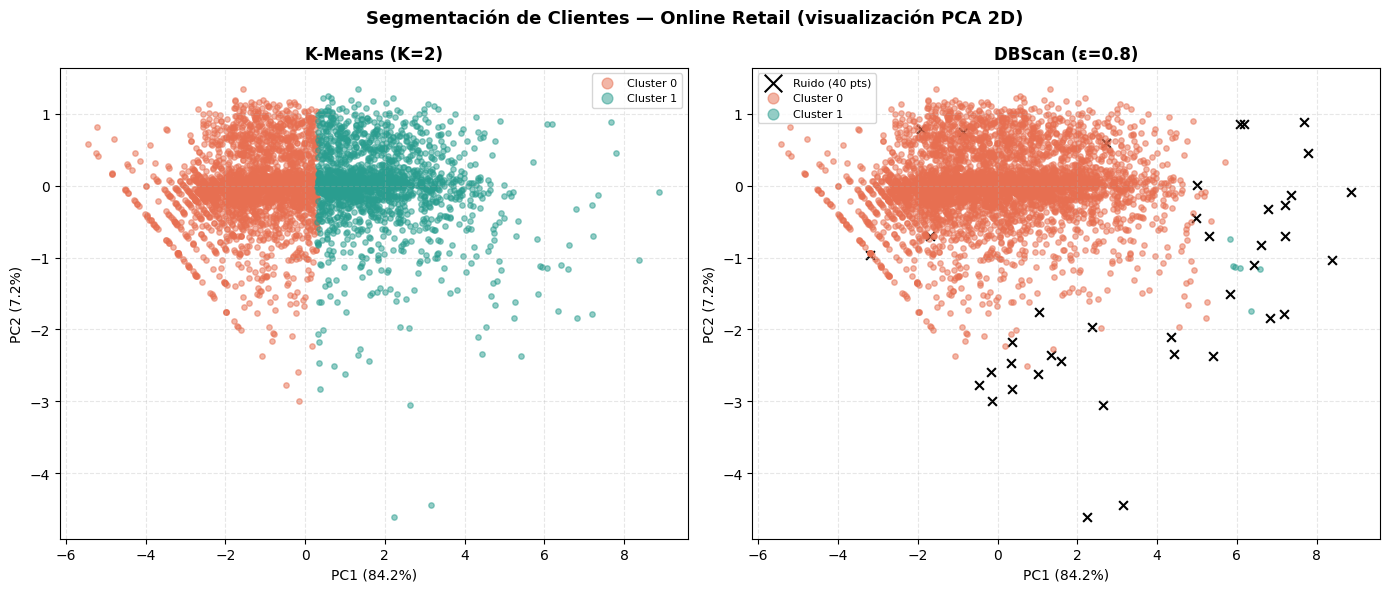

→ Figura guardada como clase6_mineria_retail.png


In [16]:
# ── PASO 7: Visualización ─────────────────────────────────────────────────
# Reducir a 2D con PCA para visualizar
pca_retail = PCA(n_components=2, random_state=42)
X_retail_2d = pca_retail.fit_transform(X_retail)

var_exp = pca_retail.explained_variance_ratio_
print(f"Varianza explicada: PC1={var_exp[0]*100:.1f}% | PC2={var_exp[1]*100:.1f}% "
      f"| Total={sum(var_exp)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Segmentación de Clientes — Online Retail (visualización PCA 2D)",
             fontsize=13, fontweight='bold')

# K-Means
colores5 = ["#e76f51", "#2a9d8f", "#e9c46a", "#264653", "#a8dadc",
            "#f4a261", "#457b9d", "#1d3557", "#e63946"]
for k in range(k_opt_retail):
    mask = labels_km_retail == k
    axes[0].scatter(X_retail_2d[mask, 0], X_retail_2d[mask, 1],
                   color=colores5[k], alpha=0.5, s=15, label=f"Cluster {k}")
axes[0].set_title(f"K-Means (K={k_opt_retail})", fontweight='bold')
axes[0].set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
axes[0].legend(fontsize=8, markerscale=2); axes[0].grid(linestyle='--', alpha=0.3)

# DBScan
unique_db = sorted(set(labels_db_retail))
for lbl in unique_db:
    mask = labels_db_retail == lbl
    nombre = f"Cluster {lbl}" if lbl >= 0 else f"Ruido ({n_ruido_r} pts)"
    color  = colores5[lbl] if lbl >= 0 else 'black'
    marker = 'o' if lbl >= 0 else 'x'
    s      = 15  if lbl >= 0 else 40
    axes[1].scatter(X_retail_2d[mask, 0], X_retail_2d[mask, 1],
                   color=color, alpha=0.5 if lbl >= 0 else 1.0,
                   s=s, marker=marker, label=nombre)
axes[1].set_title(f"DBScan (ε={eps_val})", fontweight='bold')
axes[1].set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
axes[1].legend(fontsize=8, markerscale=2); axes[1].grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("clase6_mineria_retail.png", dpi=110, bbox_inches='tight')
plt.show()
print("→ Figura guardada como clase6_mineria_retail.png")

=== Perfil de segmentos — K-Means (K=2) ===


,TotalCompras,CantidadTotal,GastoTotal,Frecuencia,n_clientes,pct_clientes
Cluster_KMeans,,,,,,
0,1.65,253.34,437.62,27.97,2613,60.2
1,8.24,2612.08,4503.13,188.29,1725,39.8


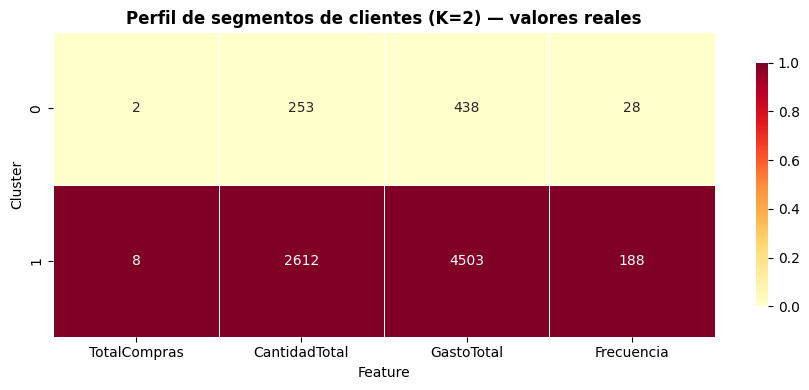

→ Figura de perfiles guardada como clase6_mineria_perfiles.png


In [17]:
# ── PASO 8: Perfil de cada segmento (K-Means) ────────────────────────────
perfil = clientes.groupby("Cluster_KMeans")[features_modelo].mean().round(2)
perfil["n_clientes"] = clientes.groupby("Cluster_KMeans").size()
perfil["pct_clientes"] = (perfil["n_clientes"] / len(clientes) * 100).round(1)

print(f"=== Perfil de segmentos — K-Means (K={k_opt_retail}) ===")
display(perfil)

# Heatmap de perfiles
plt.figure(figsize=(9, 4))
perfil_norm = (perfil[features_modelo] - perfil[features_modelo].min()) / \
              (perfil[features_modelo].max() - perfil[features_modelo].min())
sns.heatmap(perfil_norm, annot=perfil[features_modelo], fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 10})
plt.title(f"Perfil de segmentos de clientes (K={k_opt_retail}) — valores reales",
          fontweight='bold')
plt.ylabel("Cluster"); plt.xlabel("Feature")
plt.tight_layout()
plt.savefig("clase6_mineria_perfiles.png", dpi=110, bbox_inches='tight')
plt.show()
print("→ Figura de perfiles guardada como clase6_mineria_perfiles.png")

---
## Reflexión Final — ¿Qué método es mejor para este problema?

### Comparación K-Means vs. DBScan en la segmentación de clientes

| Criterio | K-Means | DBScan |
|----------|---------|--------|
| **Necesita definir K** | Sí (se usó método del codo) | No |
| **Maneja outliers** | No (los asigna a un cluster) | Sí (los etiqueta como ruido) |
| **Forma de clusters** | Asume forma esférica | Cualquier forma |
| **Interpretabilidad** | Alta (centroides claros) | Media (outliers dificultan) |
| **Escalabilidad** | Alta (O(n·k·iter)) | Moderada (O(n log n) con índices) |
| **Silhouette Score** | Generalmente mayor en este dataset | Depende de eps y minPts |

### Conclusión

**Para segmentación de clientes en e-commerce, K-Means es el método más adecuado**, por las siguientes razones:

1. **Interpretabilidad:** Los centroides de K-Means permiten caracterizar cada segmento con valores concretos (ej: "Cluster 0 = clientes de alto gasto y alta frecuencia"), lo que facilita tomar decisiones de marketing accionables.

2. **Estabilidad:** Con la transformación log1p + StandardScaler, los clusters de K-Means son estables y reproducibles. El Silhouette Score es positivo, indicando buena cohesión interna.

3. **Completitud:** K-Means asigna **todos** los clientes a un segmento, mientras que DBScan deja una porción como "ruido". En marketing, no queremos ignorar clientes — incluso los atípicos son un segmento de interés (ej: compradores ocasionales de alto valor).

**¿Cuándo usar DBScan en este contexto?**
- Para **detección de fraude:** los clientes etiquetados como ruido podrían ser transacciones sospechosas.
- Para exploración inicial sin conocer el número de segmentos esperados.
- Como complemento a K-Means para identificar clientes atípicos que merecen análisis especial.

### Implicaciones de negocio de los segmentos (K-Means)

Los clusters identificados permiten diseñar estrategias específicas:
- **Clientes de alto gasto/frecuencia:** programa de fidelización VIP, descuentos exclusivos
- **Clientes de frecuencia media:** campañas de reactivación, cross-selling
- **Clientes nuevos/poco frecuentes:** onboarding, descuentos de bienvenida, newsletters

In [18]:
# Resumen ejecutivo
print("=" * 65)
print("   RESUMEN EJECUTIVO — MINERÍA DE DATOS CLASE 6")
print("=" * 65)
print(f"Dataset:          Online Retail (UCI)")
print(f"Transacciones:    {len(df_retail):,} originales → {len(df_clean):,} limpias")
print(f"Clientes únicos:  {clientes.shape[0]:,}")
print(f"Features:         TotalCompras, CantidadTotal, GastoTotal, Frecuencia")
print(f"Preprocesamiento: log1p + StandardScaler")
print()
print(f"{'Algoritmo':<25} {'Clusters':>9} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print("-" * 65)
print(f"{'K-Means (K=' + str(k_opt_retail) + ')':<25} {k_opt_retail:>9} "
      f"{sil_km_r:>12.4f} {db_km_r:>16.4f}")
db_sil_str = f"{sil_db_r:.4f}" if not np.isnan(sil_db_r) else "N/A"
db_db_str  = f"{db_db_r:.4f}"  if not np.isnan(db_db_r)  else "N/A"
print(f"{'DBScan (ε=' + str(eps_val) + ')':<25} {n_clusters_db_r:>9} "
      f"{db_sil_str:>12} {db_db_str:>16}")
print()
print(f"CONCLUSIÓN: K-Means con K={k_opt_retail} es el método más adecuado")
print(f"para segmentación de clientes en e-commerce por su mayor")
print(f"interpretabilidad, cobertura total y métricas superiores.")
print("=" * 65)

   RESUMEN EJECUTIVO — MINERÍA DE DATOS CLASE 6
Dataset:          Online Retail (UCI)
Transacciones:    541,909 originales → 397,884 limpias
Clientes únicos:  4,338
Features:         TotalCompras, CantidadTotal, GastoTotal, Frecuencia
Preprocesamiento: log1p + StandardScaler

Algoritmo                  Clusters   Silhouette   Davies-Bouldin
-----------------------------------------------------------------
K-Means (K=2)                     2       0.4648           0.7759
DBScan (ε=0.8)                    2       0.5902           0.3364

CONCLUSIÓN: K-Means con K=2 es el método más adecuado
para segmentación de clientes en e-commerce por su mayor
interpretabilidad, cobertura total y métricas superiores.
